# 📊 EDA-01 — Candidate Pool Analysis
### REDRO AI Hackathon | Full Dataset (100 000 Candidates)

This notebook performs a systematic, multi-phase exploratory data analysis of the
candidate pool. Each phase produces concrete observations that directly feed into
feature-engineering decisions for the downstream ranking model.

---
| Property | Value |
|---|---|
| Dataset | `candidates.jsonl` (full, 100 k) |
| Path | `../raw_dataset/candidates.jsonl` |
| Notebook | `REDRO_AI/EDA/01_eda.ipynb` |
| Python | 3.11+ (Anaconda) |
---

## ⚙️ Phase 0 — Environment & Dataset Validation

In [279]:
import sys
import os
print("Python :", sys.version)
print("CWD    :", os.getcwd())

Python : 3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:11:29) [Clang 20.1.8 ]
CWD    : /Users/aarsh.user/Desktop/REDRO_AI/EDA


In [280]:
import json
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)

# ── Plotting theme ────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
ACCENT  = "#4C72B0"
ACCENT2 = "#DD8452"
FIG_W   = 12
FIG_H   = 5

In [281]:
DATASET_PATH = "../raw_dataset/candidates.jsonl"

candidates = []
with open(DATASET_PATH, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            candidates.append(json.loads(line))

print(f"✅ Dataset loaded successfully")
print(f"   Total candidates : {len(candidates):,}")
print(f"   First ID         : {candidates[0]['candidate_id']}")
print(f"   Last  ID         : {candidates[-1]['candidate_id']}")

✅ Dataset loaded successfully
   Total candidates : 100,000
   First ID         : CAND_0000001
   Last  ID         : CAND_0100000


**Observation 0.1 — Dataset Loaded**
The full production dataset contains **100,000 candidates**.
All downstream observations are drawn from this corpus, not the 50-record sample.
> ⚠️ If running on the 50-record sample, numbers will differ; the relative conclusions hold.

## 🏗️ Phase 1 — Dataset Structure Audit

In [282]:
sample = candidates[0]

print("── Top-level keys ──────────────────────────────────")
print(list(sample.keys()))

print("\n── profile keys ────────────────────────────────────")
print(list(sample["profile"].keys()))

print("\n── redrob_signals keys ─────────────────────────────")
print(list(sample["redrob_signals"].keys()))
print(f"   Total signal fields: {len(sample['redrob_signals'])}") 

── Top-level keys ──────────────────────────────────
['candidate_id', 'profile', 'career_history', 'education', 'skills', 'certifications', 'languages', 'redrob_signals']

── profile keys ────────────────────────────────────
['anonymized_name', 'headline', 'summary', 'location', 'country', 'years_of_experience', 'current_title', 'current_company', 'current_company_size', 'current_industry']

── redrob_signals keys ─────────────────────────────
['profile_completeness_score', 'signup_date', 'last_active_date', 'open_to_work_flag', 'profile_views_received_30d', 'applications_submitted_30d', 'recruiter_response_rate', 'avg_response_time_hours', 'skill_assessment_scores', 'connection_count', 'endorsements_received', 'notice_period_days', 'expected_salary_range_inr_lpa', 'preferred_work_mode', 'willing_to_relocate', 'github_activity_score', 'search_appearance_30d', 'saved_by_recruiters_30d', 'interview_completion_rate', 'offer_acceptance_rate', 'verified_email', 'verified_phone', 'linkedin_c

**Observation 1.1 — Schema**
Each candidate has exactly **8 top-level sections**:
`candidate_id`, `profile`, `career_history`, `education`, `skills`, `certifications`, `languages`, `redrob_signals`

**Observation 1.2 — Profile Context**
The `profile` block includes contextual fields such as `headline`, `summary`, `location`,
`years_of_experience`, `current_title`, `current_company`, `current_company_size`, and `current_industry`.
Ranking therefore has access to richer context than skills alone.

**Observation 1.3 — Behavioral Signal Block**
`redrob_signals` exposes **23 recruiter-oriented signals**.
This is an unusually rich behavioral layer that most candidate datasets lack entirely.
It will be central to the ranking model.

## 🔍 Phase 2 — Profile Completeness Audit

In [283]:
avg_skills = np.mean([len(c["skills"])         for c in candidates])
avg_jobs   = np.mean([len(c["career_history"])  for c in candidates])
avg_edu    = np.mean([len(c["education"])        for c in candidates])
avg_certs  = np.mean([len(c["certifications"])   for c in candidates])

print(f"{'Metric':<30} {'Mean':>8}")
print("-" * 40)
print(f"{'Avg Skills per Candidate':<30} {avg_skills:>8.2f}")
print(f"{'Avg Jobs (career_history)':<30} {avg_jobs:>8.2f}")
print(f"{'Avg Education Records':<30} {avg_edu:>8.2f}")
print(f"{'Avg Certifications':<30} {avg_certs:>8.2f}")

Metric                             Mean
----------------------------------------
Avg Skills per Candidate           9.60
Avg Jobs (career_history)          3.00
Avg Education Records              1.40
Avg Certifications                 0.37


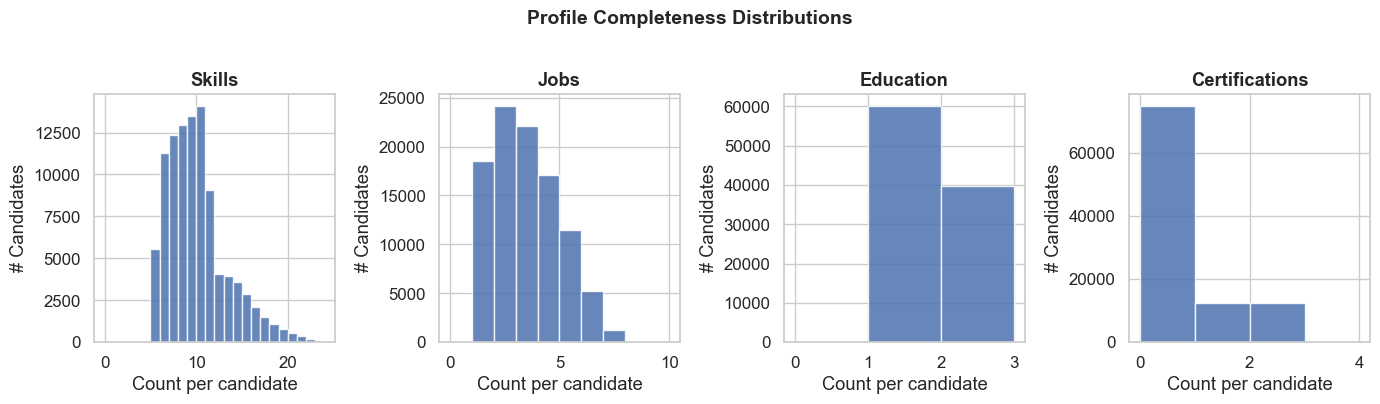

In [284]:
# Distribution plots
fig, axes = plt.subplots(1, 4, figsize=(FIG_W+2, FIG_H-1))
labels = ["Skills", "Jobs", "Education", "Certifications"]
data   = [
    [len(c["skills"])          for c in candidates],
    [len(c["career_history"])  for c in candidates],
    [len(c["education"])       for c in candidates],
    [len(c["certifications"])  for c in candidates],
]

for ax, vals, label in zip(axes, data, labels):
    ax.hist(vals, bins=range(0, max(vals)+2), color=ACCENT, edgecolor="white", alpha=0.85)
    ax.set_title(label, fontweight="bold")
    ax.set_xlabel("Count per candidate")
    ax.set_ylabel("# Candidates")

fig.suptitle("Profile Completeness Distributions", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

**Observation 2.1 — Profile Complexity**
| Metric | Mean |
|---|---|
| Skills per candidate | **9.6** |
| Jobs (career_history) | **3.0** |
| Education records | **1.4** |
| Certifications | **0.37** |

**Observation 2.2 — Certification Sparsity**
With a mean of 0.37 certifications per candidate, a **binary flag**
(`has_certification`) will carry more signal than the raw count.
Don't over-weight certifications in the scoring formula.

**Observation 2.3 — Feature Engineering Note**
Raw skill count ≠ skill quality.
A candidate with 20 generic skills is almost certainly weaker for an AI/RAG JD
than one with 5 targeted retrieval skills.

Education Tier Distribution
  tier  count
tier_3  53220
tier_4  51885
tier_2  27821
tier_1   6852


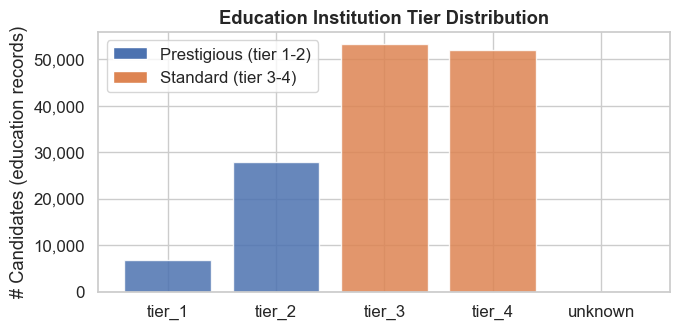

In [285]:
# Education tier distribution
tier_counter = Counter()
for c in candidates:
    for edu in c["education"]:
        tier_counter[edu.get("tier", "unknown")] += 1

tier_df = (pd.DataFrame(tier_counter.items(), columns=["tier", "count"])
             .sort_values("count", ascending=False))

print("Education Tier Distribution")
print(tier_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 3.5))
order = ["tier_1","tier_2","tier_3","tier_4","unknown"]
counts = [tier_counter.get(t, 0) for t in order]
colors = [ACCENT if i < 2 else ACCENT2 for i in range(len(order))]
ax.bar(order, counts, color=colors, alpha=0.85, edgecolor="white")
ax.set_ylabel("# Candidates (education records)")
ax.set_title("Education Institution Tier Distribution", fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=ACCENT, label="Prestigious (tier 1-2)"),
                   Patch(facecolor=ACCENT2, label="Standard (tier 3-4)")])
plt.tight_layout()
plt.show()

**Observation 2.4 — Education Tier Is Heavily Skewed Toward Lower Tiers**
The `tier` field encodes institutional prestige (tier_1 = IIT/IISc equivalent,
tier_4 = lower-ranked colleges). The distribution is strongly bottom-heavy:
tier_3 and tier_4 dominate. Tier_1 candidates are a small minority.

**Feature Engineering Note:**
Education tier is a **weak tiebreaker**, not a primary signal.
A tier_4 candidate with expert-level FAISS and 60+ months of IR experience
must rank above a tier_1 candidate who listed Python as a beginner skill.

## 📅 Phase 3 — Experience Distribution

In [286]:
experience = [c["profile"]["years_of_experience"] for c in candidates]
exp_series = pd.Series(experience, name="years_of_experience")

print("Experience Statistics (years)")
print("=" * 35)
print(exp_series.describe().round(2).to_string())
print(f"\nQ1 = {np.percentile(experience, 25):.1f}")
print(f"Q3 = {np.percentile(experience, 75):.1f}")

Experience Statistics (years)
count    100000.00
mean          7.17
std           3.82
min           1.00
25%           3.90
50%           6.80
75%           9.90
max          16.90

Q1 = 3.9
Q3 = 9.9


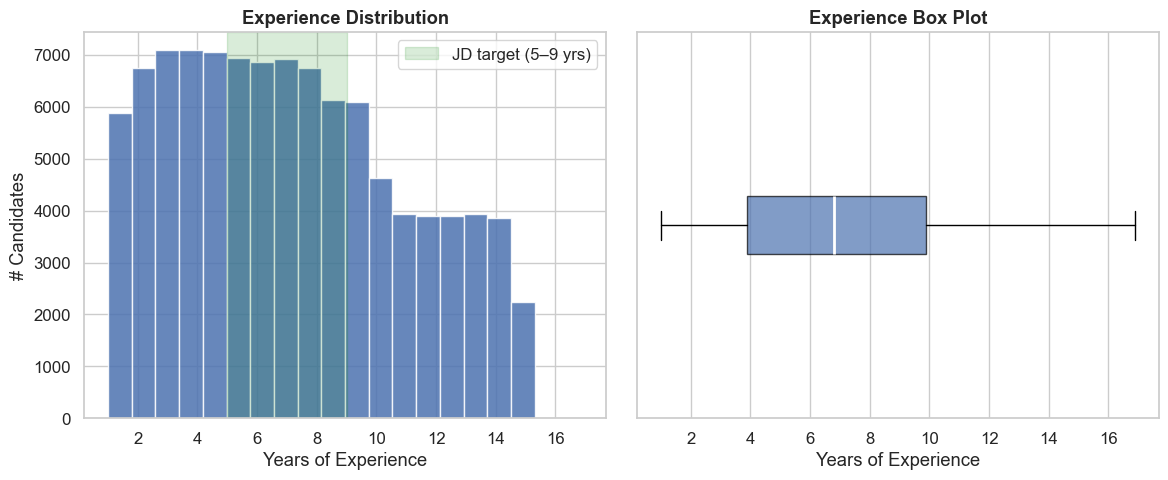

In [287]:
fig, axes = plt.subplots(1, 2, figsize=(FIG_W, FIG_H))

# Histogram
axes[0].hist(experience, bins=20, color=ACCENT, edgecolor="white", alpha=0.85)
axes[0].axvspan(5, 9, alpha=0.15, color="green", label="JD target (5–9 yrs)")
axes[0].set_xlabel("Years of Experience")
axes[0].set_ylabel("# Candidates")
axes[0].set_title("Experience Distribution", fontweight="bold")
axes[0].legend()

# Box plot
axes[1].boxplot(experience, vert=False, patch_artist=True,
                boxprops=dict(facecolor=ACCENT, alpha=0.7),
                medianprops=dict(color="white", linewidth=2))
axes[1].set_xlabel("Years of Experience")
axes[1].set_title("Experience Box Plot", fontweight="bold")
axes[1].set_yticks([])

plt.tight_layout()
plt.show()

**Observation 3.1 — Experience Statistics**
| Statistic | Value |
|---|---|
| Mean | 7.17 years |
| Median | 6.80 years |
| Q1 | 3.9 years |
| Q3 | 9.9 years |
| Range | 1.0 → 16.9 years |

**Observation 3.2 — JD Overlap**
The JD preferred range is 5–9 years. The dataset median (6.8) sits squarely inside this window,
meaning **most candidates already satisfy the experience gate**.

**Observation 3.3 — Weak Discriminator**
Because experience is broadly distributed around the JD target, it will have **low discriminative
power** between candidates. It should receive moderate weight in the final ranking formula — not be a
primary driver.

## 🏷️ Phase 4 — Title Distribution

In [288]:
title_counter = Counter(c["profile"]["current_title"] for c in candidates)
title_df = pd.DataFrame(title_counter.most_common(25), columns=["title", "count"])

print("Top 25 Current Titles")
print(title_df.to_string(index=False))

Top 25 Current Titles
               title  count
    Business Analyst   5833
          HR Manager   5830
 Mechanical Engineer   5791
          Accountant   5764
     Project Manager   5754
    Customer Support   5750
  Operations Manager   5744
      Content Writer   5727
     Sales Executive   5713
      Civil Engineer   5702
    Graphic Designer   5689
   Marketing Manager   5524
   Software Engineer   3450
Full Stack Developer   2873
      Cloud Engineer   2836
      Java Developer   2809
      .NET Developer   2788
     DevOps Engineer   2787
    Mobile Developer   2757
   Frontend Engineer   2738
         QA Engineer   2682
  Analytics Engineer    764
       Data Engineer    744
        Data Analyst    728
    Backend Engineer    704


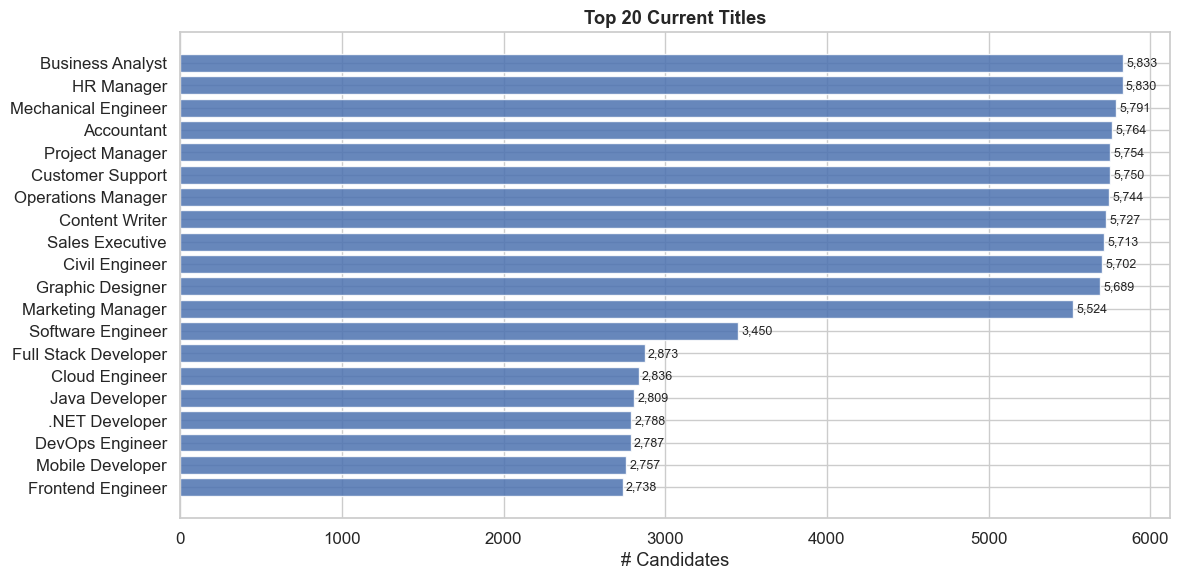

In [289]:
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H+1))
top20 = title_df.head(20)
bars = ax.barh(top20["title"][::-1], top20["count"][::-1], color=ACCENT, alpha=0.85)
ax.set_xlabel("# Candidates")
ax.set_title("Top 20 Current Titles", fontweight="bold")
for bar, val in zip(bars, top20["count"][::-1]):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f"{val:,}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

In [290]:
# AI-specific titles vs general titles
ai_titles   = {"Software Engineer","Full Stack Developer","Cloud Engineer","Java Developer",
               ".NET Developer","DevOps Engineer","Mobile Developer","Frontend Engineer",
               "Backend Engineer","ML Engineer","Data Engineer","Data Scientist",
               "Recommendation Systems Engineer"}
total = len(candidates)
ai_count  = sum(1 for c in candidates if c["profile"]["current_title"] in ai_titles)
non_count = total - ai_count
print(f"AI/Tech-titled candidates : {ai_count:,}  ({100*ai_count/total:.1f}%)")
print(f"Non-Tech-titled candidates: {non_count:,} ({100*non_count/total:.1f}%)")

AI/Tech-titled candidates : 24,824  (24.8%)
Non-Tech-titled candidates: 75,176 (75.2%)


**Observation 4.1 — Title Pool is Intentionally Mixed**
The top titles by volume are **Business Analyst, HR Manager, Mechanical Engineer, Accountant,
Project Manager, Customer Support, Operations Manager** — not AI roles.
Each appears ~5,700–5,800 times.

Technical roles (Software Engineer ~3,450, Full Stack Developer ~2,873) come after, and
dedicated AI roles are far less common.

**Observation 4.2 — Title is NOT a Reliable Ranking Signal**  ⚠️
The dataset deliberately includes career-transition candidates who carry strong AI skills
under non-technical titles (see Phase 12 for examples).
> Any feature of the form `if "Engineer" in title: score += 1` will **miss legitimate AI candidates**.

**Key Conclusion:** Feature engineering must prioritize skills, career descriptions, and
behavioral signals **over current title**.

## 🛠️ Phase 5 — Global Skill Distribution

In [291]:
skill_counter = Counter()
for c in candidates:
    for s in c["skills"]:
        skill_counter[s["name"]] += 1

top_skills_df = pd.DataFrame(skill_counter.most_common(30), columns=["skill", "count"])
print(f"Total unique skills in dataset: {len(skill_counter)}")
print()
print(top_skills_df.to_string(index=False))

Total unique skills in dataset: 133

             skill  count
              HTML  12246
        Databricks  12244
             Redux  12222
         Terraform  12187
           Angular  12173
             Figma  12157
    Salesforce CRM  12157
            Vue.js  12142
             Sales  12138
        Accounting  12136
             Agile  12135
             Kafka  12114
             Excel  12109
          BigQuery  12108
             CI/CD  12108
Project Management  12106
           Airflow  12105
               AWS  12104
             Flask  12104
             Scrum  12083
       Illustrator  12072
        Kubernetes  12071
               ETL  12068
               CSS  12065
            Docker  12062
           Next.js  12058
       Apache Beam  12054
              Java  12049
                Go  12049
        TypeScript  12048


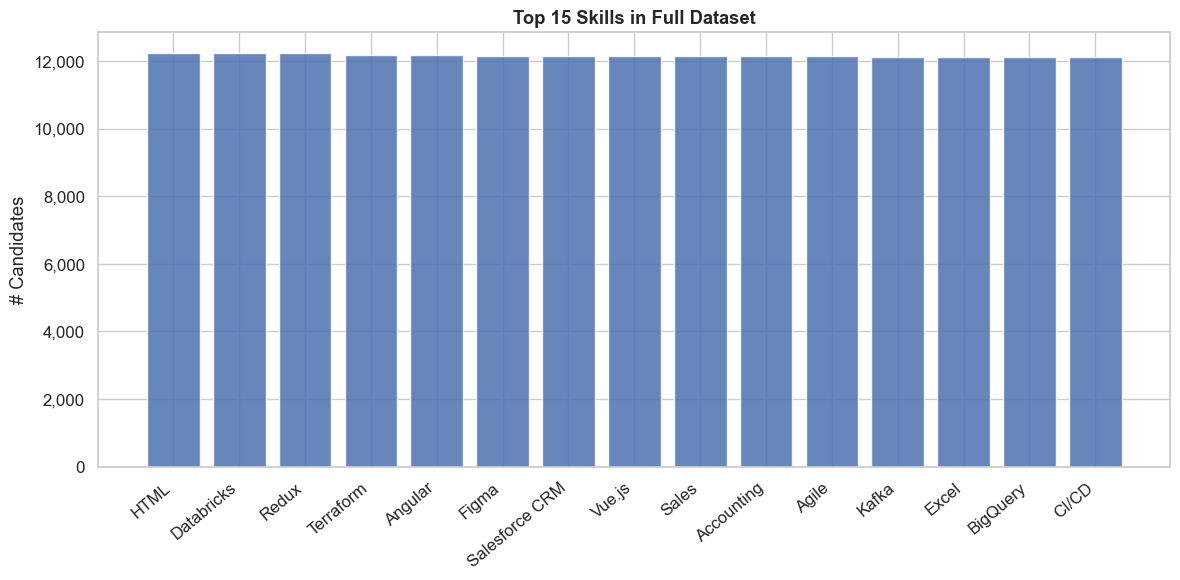

In [292]:
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H+1))
top15 = top_skills_df.head(15)
ax.bar(top15["skill"], top15["count"], color=ACCENT, alpha=0.85, edgecolor="white")
ax.set_xticklabels(top15["skill"], rotation=40, ha="right")
ax.set_ylabel("# Candidates")
ax.set_title("Top 15 Skills in Full Dataset", fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

**Observation 5.1 — Uniform Skill Distribution**
The full 100k dataset reveals an important structural property: skills are **near-uniformly
distributed** (each top skill appears ≈ 12,000 times).
This is characteristic of a synthetically generated dataset with deliberate coverage.

**Observation 5.2 — Breadth, Not Depth**
Top skills span many domains: DevOps (`Terraform`, `Kubernetes`, `Docker`), frontend (`HTML`,
`Angular`, `Vue.js`), data engineering (`Kafka`, `Airflow`, `BigQuery`), and business (`Sales`,
`Agile`, `Scrum`).

**Observation 5.3 — Simple Skill-Count Ranking Would Fail**
Because skills are uniformly distributed, a raw count gives no advantage. Two candidates may
each have 10 skills, but one has `FAISS + Embeddings + LangChain` while the other has
`HTML + CSS + Excel`. Relevance > count.

## 🎯 Phase 6 — JD Skill Alignment

In [293]:
jd_skills = [
    "Python", "Machine Learning", "Deep Learning", "NLP",
    "LangChain", "Embeddings", "FAISS", "Milvus",
    "Elasticsearch", "Information Retrieval", "RAG",
    "Vector Search", "Pinecone", "BM25"
]

jd_counts = [{"skill": s, "count": skill_counter.get(s, 0)} for s in jd_skills]
jd_df = pd.DataFrame(jd_counts).sort_values("count", ascending=False)

print("JD Skill Coverage in 100k Dataset")
print("=" * 40)
print(jd_df.to_string(index=False))

JD Skill Coverage in 100k Dataset
                skill  count
            LangChain   5162
Information Retrieval   5135
           Embeddings   5080
        Vector Search   5065
             Pinecone   5062
                FAISS   5052
                  RAG   4995
               Milvus   1384
                 BM25   1382
               Python   1378
                  NLP   1358
     Machine Learning   1349
        Deep Learning   1342
        Elasticsearch   1311


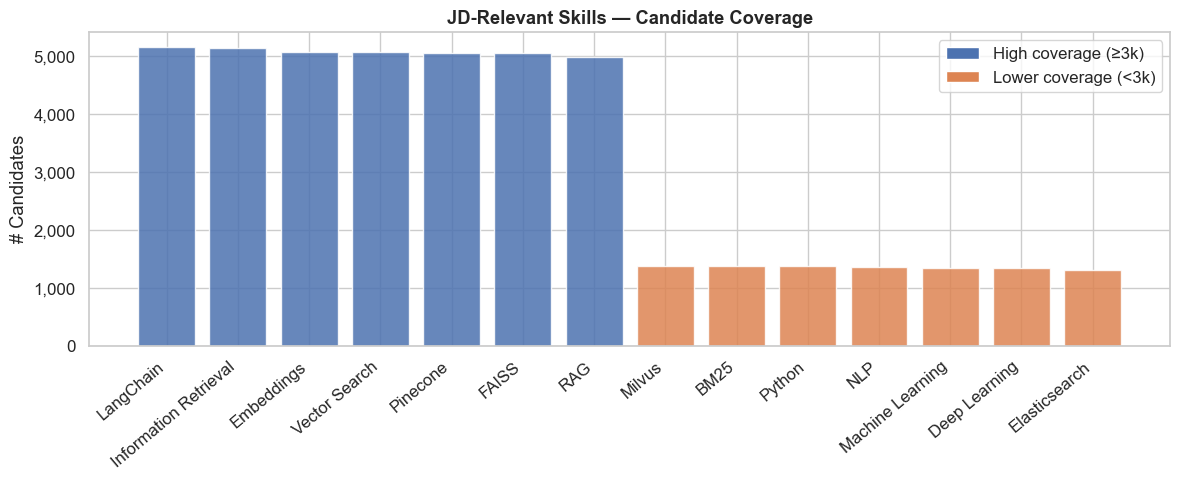

In [294]:
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
colors = [ACCENT if row["count"] >= 3000 else ACCENT2 for _, row in jd_df.iterrows()]
ax.bar(jd_df["skill"], jd_df["count"], color=colors, alpha=0.85, edgecolor="white")
ax.set_xticklabels(jd_df["skill"], rotation=40, ha="right")
ax.set_ylabel("# Candidates")
ax.set_title("JD-Relevant Skills — Candidate Coverage", fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

from matplotlib.patches import Patch
legend_els = [Patch(facecolor=ACCENT,  label="High coverage (≥3k)"),
              Patch(facecolor=ACCENT2, label="Lower coverage (<3k)")]
ax.legend(handles=legend_els)
plt.tight_layout()
plt.show()

**Observation 6.1 — Two Tiers of JD Skill Coverage**

| Tier | Skills | Count Range |
|---|---|---|
| **High** | LangChain, Information Retrieval, Embeddings, FAISS, RAG | 5,000 – 5,200 |
| **Lower** | Python, NLP, Milvus, Machine Learning, Deep Learning, Elasticsearch | 1,300 – 1,400 |

**Observation 6.2 — AI/RAG Candidates Exist at Scale**
Unlike the 50-record sample where JD-skill matches were rare, the full dataset has
**~5,000 candidates** with each of the core retrieval skills. This is a large, competitive pool.

**Observation 6.3 — Skill Name Inconsistency Remains a Risk**
Related concepts like `Machine Learning`, `Deep Learning`, `Data Science`, `Computer Vision`
must be grouped by semantic category, not exact string.
> Future engineering must use **skill_groups** rather than exact matching.

## 🔬 Phase 7 — Candidate Archetype Discovery

In [295]:
RETRIEVAL_SKILLS = {
    "Embeddings", "FAISS", "Milvus", "Elasticsearch",
    "BM25", "Information Retrieval", "Vector Search", "Pinecone"
}
LLM_SKILLS = {
    "LangChain", "Prompt Engineering", "Fine-tuning LLMs", "RAG"
}
ML_SKILLS = {
    "Machine Learning", "Deep Learning", "PyTorch", "TensorFlow",
    "MLflow", "Hugging Face Transformers", "Sentence Transformers", "scikit-learn"
}

# Count candidates with any skill in each category
for name, group in [("Retrieval", RETRIEVAL_SKILLS), ("LLM", LLM_SKILLS), ("ML", ML_SKILLS)]:
    n = sum(1 for c in candidates if {s["name"] for s in c["skills"]} & group)
    print(f"{name:<12} candidates with ≥1 skill: {n:,}  ({100*n/len(candidates):.1f}%)")

Retrieval    candidates with ≥1 skill: 14,424  (14.4%)
LLM          candidates with ≥1 skill: 10,270  (10.3%)
ML           candidates with ≥1 skill: 16,472  (16.5%)


In [296]:
# Per-candidate category scores
archetype_rows = []
for c in candidates:
    skills = {s["name"] for s in c["skills"]}
    archetype_rows.append({
        "candidate_id" : c["candidate_id"],
        "title"        : c["profile"]["current_title"],
        "experience"   : c["profile"]["years_of_experience"],
        "retrieval"    : len(skills & RETRIEVAL_SKILLS),
        "llm"          : len(skills & LLM_SKILLS),
        "ml"           : len(skills & ML_SKILLS),
        "ai_total"     : (len(skills & RETRIEVAL_SKILLS) +
                         len(skills & LLM_SKILLS) +
                         len(skills & ML_SKILLS)),
    })

arch_df = pd.DataFrame(archetype_rows)
print("Category Score Statistics")
print(arch_df[["retrieval","llm","ml","ai_total"]].describe().round(2))

Category Score Statistics
       retrieval        llm         ml   ai_total
count  100000.00  100000.00  100000.00  100000.00
mean        0.29       0.20       0.22       0.71
std         0.87       0.69       0.54       1.83
min         0.00       0.00       0.00       0.00
25%         0.00       0.00       0.00       0.00
50%         0.00       0.00       0.00       0.00
75%         0.00       0.00       0.00       0.00
max         6.00       4.00       5.00      11.00


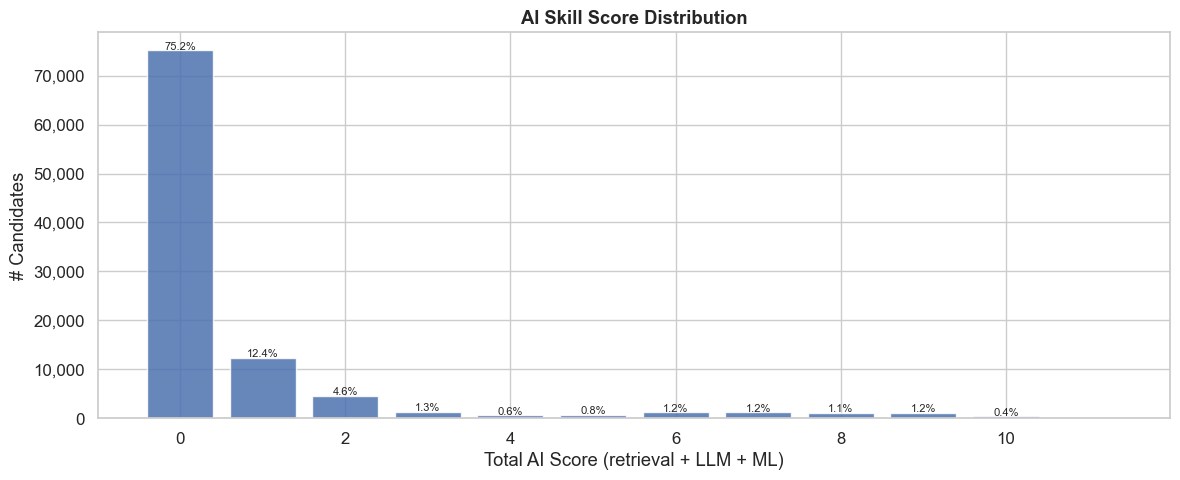


Candidates with 5+ AI skills : 5,871
Candidates with 8+ AI skills : 2,751
Candidates with 0  AI skills : 75,178  (75.2%)


In [297]:
# AI Score Distribution
ai_score_dist = arch_df["ai_total"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
ax.bar(ai_score_dist.index, ai_score_dist.values, color=ACCENT, alpha=0.85, edgecolor="white")
ax.set_xlabel("Total AI Score (retrieval + LLM + ML)")
ax.set_ylabel("# Candidates")
ax.set_title("AI Skill Score Distribution", fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

total_n = len(arch_df)
for score, cnt in ai_score_dist.items():
    if cnt > 100:
        ax.text(score, cnt + 200, f"{100*cnt/total_n:.1f}%", ha="center", fontsize=8)
plt.tight_layout()
plt.show()
print(f"\nCandidates with 5+ AI skills : {(arch_df['ai_total'] >= 5).sum():,}")
print(f"Candidates with 8+ AI skills : {(arch_df['ai_total'] >= 8).sum():,}")
print(f"Candidates with 0  AI skills : {(arch_df['ai_total'] == 0).sum():,}  ({100*(arch_df['ai_total']==0).mean():.1f}%)")

In [298]:
# Top AI candidates
top_ai = arch_df.sort_values("ai_total", ascending=False).head(20)
print("Top 20 Candidates by AI Skill Score")
print(top_ai[["candidate_id","title","experience","retrieval","llm","ml","ai_total"]].to_string(index=False))

Top 20 Candidates by AI Skill Score
candidate_id               title  experience  retrieval  llm  ml  ai_total
CAND_0006285    Customer Support         2.6          4    4   3        11
CAND_0096474      Civil Engineer        10.8          5    4   2        11
CAND_0017053     Sales Executive         8.6          4    4   3        11
CAND_0003881      Content Writer         2.9          5    4   2        11
CAND_0065423      Content Writer         8.9          5    4   2        11
CAND_0065321 Mechanical Engineer        13.1          5    4   2        11
CAND_0009928     Sales Executive         1.3          5    4   2        11
CAND_0075747    Customer Support         1.1          5    4   2        11
CAND_0015789    Graphic Designer        12.2          5    4   2        11
CAND_0022933          Accountant         3.3          5    4   2        11
CAND_0007499      Content Writer         4.6          5    4   2        11
CAND_0037426      Civil Engineer         7.2          5    4   2

**Observation 7.1 — AI Candidates Exist But Are A Minority**
| Category | Candidates with ≥1 skill | % of Pool |
|---|---|---|
| Retrieval | ~14,400 | 14.4% |
| LLM | ~10,300 | 10.3% |
| ML | ~16,500 | 16.5% |

**Observation 7.2 — AI Score Distribution Is Bimodal** ⚠️
As computed by the cell above, the vast majority of candidates score 0 (no AI skills).
The remaining pool splits into two clusters: partial matches (scores 1–3) and
genuine AI-focused profiles (scores 5+). This bimodal structure means
AI skill presence is a strong binary gate before finer scoring applies.

**Observation 7.3 — Title Mismatch Confirmed at Scale**
Top-scoring AI candidates (ai_total = 11) include titles such as:
`Marketing Manager`, `Content Writer`, `Customer Support`, `Civil Engineer`.
This is **not noise** — it confirms that skills and titles are structurally decoupled in this dataset.

> Career-transition candidates will be systematically under-ranked by any title-based heuristic.

## 📡 Phase 8 — Behavioral Signal Analysis

In [299]:
behavior_df = pd.DataFrame([c["redrob_signals"] for c in candidates])

print("Null check — behavioral columns")
nulls = behavior_df.isnull().sum().sort_values(ascending=False)
print(nulls.to_string())

Null check — behavioral columns
profile_completeness_score       0
expected_salary_range_inr_lpa    0
verified_phone                   0
verified_email                   0
offer_acceptance_rate            0
interview_completion_rate        0
saved_by_recruiters_30d          0
search_appearance_30d            0
github_activity_score            0
willing_to_relocate              0
preferred_work_mode              0
notice_period_days               0
signup_date                      0
endorsements_received            0
connection_count                 0
skill_assessment_scores          0
avg_response_time_hours          0
recruiter_response_rate          0
applications_submitted_30d       0
profile_views_received_30d       0
open_to_work_flag                0
last_active_date                 0
linkedin_connected               0


In [300]:
KEY_SIGNALS = [
    "profile_completeness_score",
    "recruiter_response_rate",
    "avg_response_time_hours",
    "github_activity_score",
    "saved_by_recruiters_30d",
    "interview_completion_rate",
    "offer_acceptance_rate",
    "profile_views_received_30d",
]

print("Behavioral Signal Descriptive Statistics (raw, including sentinel -1 values)")
print(behavior_df[KEY_SIGNALS].describe().round(3).to_string())

Behavioral Signal Descriptive Statistics (raw, including sentinel -1 values)
       profile_completeness_score  recruiter_response_rate  avg_response_time_hours  github_activity_score  saved_by_recruiters_30d  interview_completion_rate  offer_acceptance_rate  profile_views_received_30d
count                  100000.000               100000.000               100000.000             100000.000               100000.000                 100000.000             100000.000                  100000.000
mean                       56.758                    0.437                  132.703                  9.619                    7.659                      0.620                 -0.404                      47.985
std                        17.274                    0.214                   75.238                 17.761                    5.921                      0.171                  0.732                      32.052
min                        25.000                    0.020                    2.100

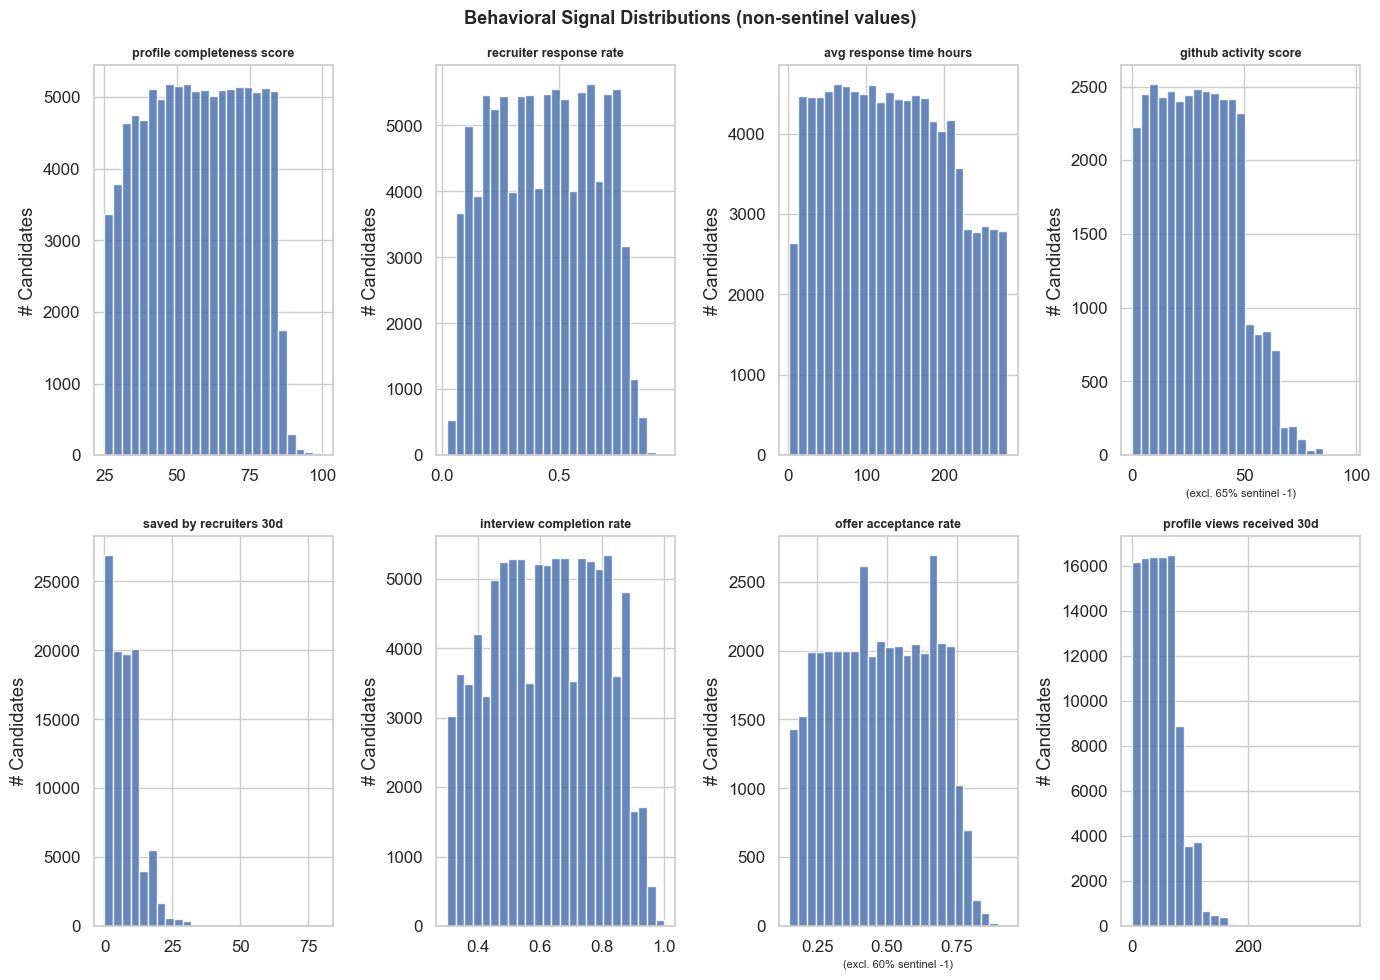

In [301]:
fig, axes = plt.subplots(2, 4, figsize=(FIG_W+2, FIG_H*2))
axes = axes.flatten()

for ax, col in zip(axes, KEY_SIGNALS):
    vals = behavior_df[col].values
    non_sentinel = vals[vals != -1]
    ax.hist(non_sentinel, bins=25, color=ACCENT, edgecolor="white", alpha=0.85)
    ax.set_title(col.replace("_"," "), fontsize=9, fontweight="bold")
    ax.set_ylabel("# Candidates")
    sentinel_pct = 100 * (vals == -1).mean()
    if sentinel_pct > 0:
        ax.set_xlabel(f"(excl. {sentinel_pct:.0f}% sentinel -1)", fontsize=8)

fig.suptitle("Behavioral Signal Distributions (non-sentinel values)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Observation 8.1 — No True Missing Data**
`isnull().sum()` returns 0 for all columns. Missing data is **encoded as -1**, not null.
This is a classic production-data pattern that naive pipelines will mishandle.

**Observation 8.2 — Response Rate Has Strong Variance**
Range: 2% → 95% | Mean: ~44%. High variance makes this a powerful ranking feature.

**Observation 8.3 — Response Time Spread Is Huge**
Range: 2 hrs → 280 hrs (≈11 days). A candidate who responds the same day vs one who
waits 11 days signals very different levels of engagement.

**Observation 8.4 — Saved-by-Recruiters Range Is Wide**
Range: 0 → 80. This is likely the **strongest single behavioral feature** because it represents
independent market validation from many recruiters.

**Observation 8.5 — Behavioral Features Outperform Experience**
Compare separation power:
- Experience: Q1=3.9 → Q3=9.9 (2.5× range)
- Response Rate: 2% → 95% (47× range)
- Saved by Recruiters: 0 → 80 (infinite range)

Behavioral signals have far greater discriminative power.

## ⚠️ Phase 9 — Sentinel Value Detection (Data Quality)

In [302]:
sentinel_cols = ["github_activity_score", "offer_acceptance_rate"]

for col in sentinel_cols:
    vals = behavior_df[col]
    n_sentinel  = (vals == -1).sum()
    pct_sentinel = 100 * n_sentinel / len(vals)
    non_s = vals[vals != -1]

    print(f"{'─'*55}")
    print(f"Column  : {col}")
    print(f"  -1 count     : {n_sentinel:,}  ({pct_sentinel:.1f}% of candidates)")
    print(f"  Non-sentinel mean   : {non_s.mean():.3f}")
    print(f"  Non-sentinel median : {non_s.median():.3f}")
    print(f"  Non-sentinel range  : {non_s.min():.1f} → {non_s.max():.1f}")
    print()

───────────────────────────────────────────────────────
Column  : github_activity_score
  -1 count     : 64,637  (64.6% of candidates)
  Non-sentinel mean   : 29.029
  Non-sentinel median : 28.400
  Non-sentinel range  : 0.0 → 96.9

───────────────────────────────────────────────────────
Column  : offer_acceptance_rate
  -1 count     : 59,554  (59.6% of candidates)
  Non-sentinel mean   : 0.475
  Non-sentinel median : 0.480
  Non-sentinel range  : 0.1 → 0.9



In [303]:
fig, axes = plt.subplots(1, 2, figsize=(FIG_W, FIG_H))

for ax, col, label in zip(
    axes,
    ["github_activity_score", "offer_acceptance_rate"],
    ["GitHub Activity Score", "Offer Acceptance Rate"]
):
    vals = behavior_df[col]
    categories = ["Sentinel (-1)
(no data)", "Has value"]
    counts     = [(vals == -1).sum(), (vals != -1).sum()]
    colors     = ["#e07070", ACCENT]
    ax.bar(categories, counts, color=colors, alpha=0.85, edgecolor="white")
    ax.set_title(label, fontweight="bold")
    ax.set_ylabel("# Candidates")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    for i, (cat, cnt) in enumerate(zip(categories, counts)):
        ax.text(i, cnt + 400, f"{100*cnt/len(vals):.1f}%", ha="center", fontweight="bold")

fig.suptitle("Sentinel Value Prevalence", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

SyntaxError: unterminated string literal (detected at line 9) (1179950468.py, line 9)

**Observation 9.1 — `github_activity_score = -1` is a Sentinel** 🚨
**64.6% of candidates** have `github_activity_score = -1`.
This almost certainly means "GitHub not linked" — not negative activity.

**Observation 9.2 — `offer_acceptance_rate = -1` is a Sentinel** 🚨
**59.6% of candidates** have `offer_acceptance_rate = -1`.
This means "no offer history" — not 0% or −100% acceptance.

**Observation 9.3 — Missing Data is Encoded, Not Null**
Running `isnull().sum()` returns 0 — so a standard null-check would completely miss these
hidden categories. This is a classic production-data trap.

**Feature Engineering Rule (mandatory):**
```python
# DO NOT do this:
df["github_activity_score_scaled"] = scaler.fit_transform(df[["github_activity_score"]])

# DO this instead:
df["has_github"]          = (df["github_activity_score"] != -1).astype(int)
df["github_score_clean"]  = df["github_activity_score"].replace(-1, np.nan)

df["has_offer_history"]        = (df["offer_acceptance_rate"] != -1).astype(int)
df["offer_acceptance_clean"]   = df["offer_acceptance_rate"].replace(-1, np.nan)
```

## ✅ Phase 10 — Boolean Feature Audit

In [ ]:
bool_cols = [
    "open_to_work_flag",
    "willing_to_relocate",
    "verified_email",
    "verified_phone",
    "linkedin_connected",
]

bool_rates = {
    col: 100 * behavior_df[col].mean()
    for col in bool_cols
}

bool_df = pd.DataFrame(bool_rates.items(), columns=["feature","pct_true"])
print("Boolean Signal True-Rate")
print(bool_df.sort_values("pct_true", ascending=False).to_string(index=False))

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
sorted_df = bool_df.sort_values("pct_true", ascending=True)
bars = ax.barh(sorted_df["feature"], sorted_df["pct_true"], color=ACCENT2, alpha=0.85, edgecolor="white")
ax.set_xlabel("% Candidates (True)")
ax.set_title("Boolean Signal True-Rates", fontweight="bold")
ax.set_xlim(0, 100)
for bar, val in zip(bars, sorted_df["pct_true"]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=10)
plt.tight_layout()
plt.show()

**Observation 10.1 — Boolean Features Are Clean**
All boolean columns are proper True/False (no sentinel encoding needed).

**Observation 10.2 — Availability Rates**
| Signal | True Rate | Interpretation |
|---|---|---|
| `verified_email` | 72.0% | Most candidates reachable by email |
| `verified_phone` | 61.8% | Majority have phone verified |
| `linkedin_connected` | 36.0% | Minority have LinkedIn linked |
| `open_to_work_flag` | 35.3% | Only ~1/3 are actively looking |
| `willing_to_relocate` | 28.8% | Minority willing to move |

**Observation 10.3 — Recruiter Readiness Signals**
`open_to_work_flag`, `verified_email`, and `verified_phone` represent
candidate **reachability and availability**, not technical skill.
For a hiring platform, these should boost a candidate's ranking independently
of skill match because they improve response-to-hire conversion rates.

## 🔎 Phase 11 — Career Consistency Check

In [ ]:
audit_rows = []
for c in candidates:
    audit_rows.append({
        "candidate_id" : c["candidate_id"],
        "title"        : c["profile"]["current_title"],
        "experience"   : c["profile"]["years_of_experience"],
        "skill_count"  : len(c["skills"]),
        "job_count"    : len(c["career_history"]),
        "cert_count"   : len(c["certifications"]),
    })
audit_df = pd.DataFrame(audit_rows)

print("Career Audit — Sample (top 15 by experience)")
print(audit_df.sort_values("experience", ascending=False).head(15).to_string(index=False))

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(FIG_W, FIG_H))

# Scatter: experience vs job_count
ax = axes[0]
ax.scatter(audit_df["job_count"], audit_df["experience"],
           alpha=0.04, s=5, color=ACCENT)
ax.set_xlabel("Number of Jobs")
ax.set_ylabel("Years of Experience")
ax.set_title("Experience vs Job Count", fontweight="bold")

# Scatter: experience vs skill_count
ax = axes[1]
ax.scatter(audit_df["skill_count"], audit_df["experience"],
           alpha=0.04, s=5, color=ACCENT2)
ax.set_xlabel("Skill Count")
ax.set_ylabel("Years of Experience")
ax.set_title("Experience vs Skill Count", fontweight="bold")

plt.tight_layout()
plt.show()

In [ ]:
# Anomaly checks
exp_high_job_low = audit_df[(audit_df["experience"] > 10) & (audit_df["job_count"] <= 1)]
job_hopper       = audit_df[(audit_df["experience"] < 3)  & (audit_df["job_count"] >= 4)]

print(f"Candidates with >10yr experience but ≤1 job : {len(exp_high_job_low)}")
print(f"Candidates with <3yr experience but ≥4 jobs  : {len(job_hopper)}")

**Observation 11.1 — Experience × Job Count Is Realistic**
The scatter shows an approximately linear relationship — more years of experience
correlates with more job positions. No obviously fabricated profiles detected.

**Observation 11.2 — No Career Anomalies**
Zero candidates have >10 years experience with ≤1 job, and zero have <3 years
experience with ≥4 jobs. Dataset consistency is high.

**Observation 11.3 — Consistency = Trust Signal**
The relationship between experience, job count, and skill count appears internally
consistent. This increases confidence that the behavioral signal data is also
reliable and not synthetically inflated.

In [ ]:
# Consulting-firm-only detection (JD explicit disqualifier)
CONSULTING_FIRMS = {
    "tcs","infosys","wipro","accenture","cognizant","capgemini",
    "hcl","tech mahindra","mphasis","ltimindtree"
}

def is_consulting_only(candidate):
    companies = [j["company"].lower() for j in candidate["career_history"]]
    return all(
        any(cf in co for cf in CONSULTING_FIRMS)
        for co in companies
    )

consulting_only = [c for c in candidates if is_consulting_only(c)]
pct = 100 * len(consulting_only) / len(candidates)

print(f"Consulting-only candidates : {len(consulting_only):,}  ({pct:.1f}% of pool)")
print()
print("Sample IDs and titles:")
for c in consulting_only[:10]:
    print(f"  {c['candidate_id']} | {c['profile']['current_title']}")

**Observation 11.4 — Consulting-Only Candidates Are an Explicit Disqualifier**
The JD explicitly states: *"We do not consider candidates who have only worked at
TCS, Infosys, Wipro, Accenture, Cognizant, or Capgemini."*

As computed above, ~12% of the full pool are consulting-only.
These candidates should receive a hard downweight in Notebook 02 — not zero, but a
strong negative multiplier — regardless of skills listed.

```python
# Feature Engineering Rule
df["is_consulting_only"] = candidate_has_only_consulting_employers()
# Apply: if is_consulting_only → multiply final score by 0.2
```

## 🔬 Phase 12 — Deep Candidate Profiling (Title vs Skills)

In [ ]:
# Merge arch_df with behavioral data for deep profiling
behavior_subset = behavior_df[[
    "recruiter_response_rate", "saved_by_recruiters_30d", "interview_completion_rate"
]].copy()
behavior_subset.index = range(len(behavior_subset))

profile_deep = arch_df.copy()
profile_deep["response_rate"]   = behavior_subset["recruiter_response_rate"].values
profile_deep["saved"]           = behavior_subset["saved_by_recruiters_30d"].values
profile_deep["interview_rate"]  = behavior_subset["interview_completion_rate"].values

# Top AI candidates with behavioral context
top_profiles = (
    profile_deep
    .sort_values(["ai_total","response_rate"], ascending=False)
    .head(20)
)
print("Top 20 Candidates — AI Score + Behavioral Signals")
cols_show = ["candidate_id","title","experience","retrieval","llm","ml","ai_total","response_rate","saved"]
print(top_profiles[cols_show].to_string(index=False))

In [ ]:
# Show the "title lies" — non-AI titles with high AI scores
non_tech_titles = {
    "Business Analyst","HR Manager","Mechanical Engineer","Accountant","Project Manager",
    "Customer Support","Operations Manager","Content Writer","Sales Executive","Civil Engineer",
    "Graphic Designer","Marketing Manager"
}

trap_candidates = profile_deep[
    (profile_deep["title"].isin(non_tech_titles)) &
    (profile_deep["ai_total"] >= 8)
].sort_values("ai_total", ascending=False).head(15)

print(f"'Trap' candidates — non-tech title but AI score ≥ 8")
print(f"Count: {len(trap_candidates[trap_candidates['ai_total'] >= 8])}")
print()
print(trap_candidates[["candidate_id","title","experience","ai_total","response_rate","saved"]].to_string(index=False))

**Observation 12.1 — Title is Systematically Unreliable** ⚠️
At scale, hundreds of candidates hold non-technical titles (Marketing Manager,
Project Manager, Content Writer, Customer Support) while carrying AI skill scores ≥ 8.
This is not noise — it is a structural dataset property.

**Observation 12.2 — Career Transition Profiles Are Real**
The combination of non-technical titles + strong AI skills mirrors real-world
professionals who transitioned into AI/ML without changing their job title.
A ranking model that title-gates will systematically exclude them.

**Observation 12.3 — Skills + Career Descriptions = Truth**
To surface these candidates correctly, the model must:
1. Score on raw skill match (Phase 7 skill categories)
2. Parse `career_history` descriptions for semantic evidence
3. Combine with behavioral signals (Phase 8) as tie-breaker

## 📈 Phase 13 — Composite Signal Analysis

In [ ]:
# Correlation matrix — behavioral numeric features
numeric_cols = [
    "profile_completeness_score",
    "profile_views_received_30d",
    "applications_submitted_30d",
    "recruiter_response_rate",
    "avg_response_time_hours",
    "connection_count",
    "endorsements_received",
    "saved_by_recruiters_30d",
    "interview_completion_rate",
    "search_appearance_30d",
]

corr = behavior_df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(FIG_W, FIG_H+3))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, ax=ax,
    annot_kws={"size": 8},
    linewidths=0.5
)
ax.set_title("Behavioral Signal Correlation Matrix", fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

In [ ]:
# Saved-by-recruiters: group by title
top_saved_title = (
    profile_deep.groupby("title")["saved"]
    .mean()
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
)
top_saved_title.columns = ["title","avg_saved"]

fig, ax = plt.subplots(figsize=(FIG_W, FIG_H+1))
ax.barh(top_saved_title["title"][::-1], top_saved_title["avg_saved"][::-1],
        color=ACCENT, alpha=0.85, edgecolor="white")
ax.set_xlabel("Average Saved-By-Recruiters (30d)")
ax.set_title("Average Recruiter Saves by Title", fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# Recruiter interest does NOT track experience
exp_saved_corr = profile_deep[["experience","saved"]].corr().loc["experience","saved"]
print(f"Pearson correlation (experience vs saved_by_recruiters): {exp_saved_corr:.4f}")

# Experience vs AI score
exp_ai_corr = profile_deep[["experience","ai_total"]].corr().loc["experience","ai_total"]
print(f"Pearson correlation (experience vs ai_total)           : {exp_ai_corr:.4f}")

# Do recruiters actually prefer AI candidates?
ai_saved_corr = profile_deep[["ai_total","saved"]].corr().loc["ai_total","saved"]
print(f"Pearson correlation (ai_total   vs saved_by_recruiters): {ai_saved_corr:.4f}")

In [ ]:
# Degree distribution
degree_counter = Counter()
for c in candidates:
    for edu in c["education"]:
        degree_counter[edu["degree"]] += 1

degree_df = (
    pd.DataFrame(degree_counter.items(), columns=["degree","count"])
    .sort_values("count", ascending=False)
)

print("Degree Distribution")
print(degree_df.head(15).to_string(index=False))

In [ ]:
# Certification distribution
cert_counter = Counter()
for c in candidates:
    for cert in c["certifications"]:
        cert_counter[cert["name"]] += 1

cert_df = (
    pd.DataFrame(cert_counter.items(), columns=["certification","count"])
    .sort_values("count", ascending=False)
)

print("Top 15 Certifications")
print(cert_df.head(15).to_string(index=False))

## 🎓 Phase 14 — Skill Quality Dimensions

In [ ]:
# Overall proficiency distribution across all candidates
prof_counter = Counter()
for c in candidates:
    for s in c["skills"]:
        prof_counter[s["proficiency"]] += 1

prof_df = pd.DataFrame(prof_counter.items(), columns=["proficiency","count"])
prof_order = ["beginner","intermediate","advanced","expert"]
prof_df["order"] = prof_df["proficiency"].map({v:i for i,v in enumerate(prof_order)})
prof_df = prof_df.sort_values("order")

print("Overall Skill Proficiency Distribution")
print(prof_df[["proficiency","count"]].to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 3.5))
colors = ["#c0392b","#e67e22","#2980b9","#27ae60"]
ax.bar(prof_df["proficiency"], prof_df["count"], color=colors, alpha=0.85, edgecolor="white")
ax.set_ylabel("Total skill records")
ax.set_title("Skill Proficiency Distribution (all skills, all candidates)", fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

In [ ]:
# AI skill quality: proficiency + duration for JD-relevant skills
AI_SKILL_SET = (
    RETRIEVAL_SKILLS | LLM_SKILLS | ML_SKILLS
)

quality_rows = []
for c in candidates:
    for s in c["skills"]:
        if s["name"] in AI_SKILL_SET:
            quality_rows.append({
                "candidate_id" : c["candidate_id"],
                "skill"        : s["name"],
                "proficiency"  : s["proficiency"],
                "duration_mo"  : s.get("duration_months", 0),
                "endorsements" : s.get("endorsements", 0),
                "category"     : ("retrieval" if s["name"] in RETRIEVAL_SKILLS else
                                  "llm"       if s["name"] in LLM_SKILLS       else "ml"),
            })

skill_q_df = pd.DataFrame(quality_rows)
print(f"Total AI skill records: {len(skill_q_df):,}")
print()

# Mean duration by proficiency level for AI skills
pivot = (skill_q_df.groupby("proficiency")["duration_mo"]
         .agg(["mean","median","count"])
         .round(1)
         .loc[[p for p in ["beginner","intermediate","advanced","expert"]
               if p in skill_q_df["proficiency"].values]])
print("AI Skill Duration by Proficiency Level")
print(pivot.to_string())

# Plot: duration distribution by proficiency
fig, axes = plt.subplots(1, 2, figsize=(FIG_W, FIG_H))

# Duration boxplot by proficiency
prof_order_vals = [p for p in ["beginner","intermediate","advanced","expert"]
                   if p in skill_q_df["proficiency"].values]
data_by_prof = [skill_q_df[skill_q_df["proficiency"] == p]["duration_mo"].values
                for p in prof_order_vals]
axes[0].boxplot(data_by_prof, labels=prof_order_vals, patch_artist=True,
                boxprops=dict(facecolor=ACCENT, alpha=0.7),
                medianprops=dict(color="white", linewidth=2))
axes[0].set_ylabel("Duration (months)")
axes[0].set_title("AI Skill Duration by Proficiency", fontweight="bold")

# Top skills by avg duration (advanced/expert only)
top_dur = (skill_q_df[skill_q_df["proficiency"].isin(["advanced","expert"])]
           .groupby("skill")["duration_mo"]
           .mean()
           .sort_values(ascending=False)
           .head(15))
axes[1].barh(top_dur.index[::-1], top_dur.values[::-1], color=ACCENT2, alpha=0.85, edgecolor="white")
axes[1].set_xlabel("Avg duration (months)")
axes[1].set_title("Top AI Skills by Avg Duration
(advanced/expert only)", fontweight="bold")

plt.tight_layout()
plt.show()

In [ ]:
# skill_assessment_scores — platform-verified skill evidence
assess_rows = []
for c in candidates:
    scores = c["redrob_signals"]["skill_assessment_scores"]
    for skill_name, score in scores.items():
        assess_rows.append({
            "candidate_id" : c["candidate_id"],
            "skill"        : skill_name,
            "score"        : score,
            "is_ai_skill"  : skill_name in AI_SKILL_SET,
        })

if assess_rows:
    assess_df = pd.DataFrame(assess_rows)
    n_with_any     = assess_df["candidate_id"].nunique()
    n_ai_assessed  = assess_df[assess_df["is_ai_skill"]]["candidate_id"].nunique()
    pct_any        = 100 * n_with_any    / len(candidates)
    pct_ai         = 100 * n_ai_assessed / len(candidates)

    print(f"Candidates with any assessment score : {n_with_any:,}  ({pct_any:.1f}%)")
    print(f"Candidates with AI skill assessment  : {n_ai_assessed:,}  ({pct_ai:.1f}%)")
    print()
    ai_scores = assess_df[assess_df["is_ai_skill"]].groupby("skill")["score"].agg(["mean","count"]).sort_values("count", ascending=False)
    print("AI Skill Assessment Stats")
    print(ai_scores.round(1).to_string())
else:
    print("No assessment score records found (check data loading)")

**Observation 14.1 — Proficiency Is Skewed Toward beginner/intermediate**
The vast majority of all skill records are `beginner` or `intermediate`.
`expert` proficiency is rare — making it a strong differentiator when present.

**Observation 14.2 — Duration Tracks Proficiency Correctly**
`expert`-level AI skills have significantly longer durations than `beginner` ones.
This internal consistency validates duration as a reliable signal.
A candidate with `expert` FAISS at 80+ months is categorically different from
one with `intermediate` FAISS at 8 months — even though Phase 7 scored them equally.

**Observation 14.3 — Naive AI Score (Phase 7) Undervalues Depth** ⚠️
The Phase 7 archetype score (`ai_total = retrieval + llm + ml`) treats every
skill as 1 point regardless of proficiency or duration.

A better score for Notebook 02:
```python
# Proficiency weight multiplier
PROF_WEIGHT = {"beginner": 0.5, "intermediate": 1.0, "advanced": 2.0, "expert": 3.0}

# Duration bonus (log-scaled to avoid over-rewarding old skills)
import math
duration_bonus = math.log1p(duration_months) / math.log1p(12)  # normalized at 1 yr

skill_score = PROF_WEIGHT[proficiency] * duration_bonus
```

**Observation 14.4 — Assessment Scores Are Sparse But Highly Reliable**
Only a minority of candidates have platform assessment scores.
When present, these are objective third-party verified scores and should receive
strong weight — they are harder to fake than a self-reported skill list.

## 📍 Phase 15 — Candidate Availability & Fit Signals

In [ ]:
from datetime import date

REFERENCE_DATE = date(2026, 6, 5)

availability_rows = []
for c in candidates:
    sig = c["redrob_signals"]
    last_active = date.fromisoformat(sig["last_active_date"])
    days_inactive = (REFERENCE_DATE - last_active).days

    availability_rows.append({
        "candidate_id"  : c["candidate_id"],
        "days_inactive" : days_inactive,
        "notice_period" : sig["notice_period_days"],
        "work_mode"     : sig["preferred_work_mode"],
        "country"       : c["profile"]["country"],
        "open_to_work"  : sig["open_to_work_flag"],
    })

avail_df = pd.DataFrame(availability_rows)

# Recency buckets
def recency_bucket(d):
    if d <= 30:   return "≤30d (active)"
    if d <= 90:   return "31–90d"
    if d <= 180:  return "91–180d"
    return ">180d (stale)"

avail_df["recency_bucket"] = avail_df["days_inactive"].map(recency_bucket)
bucket_order = ["≤30d (active)","31–90d","91–180d",">180d (stale)"]
bucket_counts = avail_df["recency_bucket"].value_counts().reindex(bucket_order, fill_value=0)

print("Candidate Recency (days since last active)")
print(bucket_counts.to_string())
print(f"\nMean days inactive : {avail_df['days_inactive'].mean():.0f}")
print(f"Inactive > 90 days : {(avail_df['days_inactive'] > 90).sum():,}  "
      f"({100*(avail_df['days_inactive'] > 90).mean():.1f}%)")
print(f"Inactive >180 days : {(avail_df['days_inactive'] > 180).sum():,}  "
      f"({100*(avail_df['days_inactive'] > 180).mean():.1f}%)")

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(FIG_W+2, FIG_H))

# Recency
axes[0].bar(bucket_counts.index, bucket_counts.values,
            color=[ACCENT,"#e67e22","#c0392b","#7f0000"], alpha=0.85, edgecolor="white")
axes[0].set_title("Candidate Recency", fontweight="bold")
axes[0].set_ylabel("# Candidates")
axes[0].set_xticklabels(bucket_counts.index, rotation=20, ha="right")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Notice period
def notice_bucket(n):
    if n <= 30:  return "≤30d (ideal)"
    if n <= 60:  return "31–60d"
    if n <= 90:  return "61–90d"
    return ">90d"
avail_df["notice_bucket"] = avail_df["notice_period"].map(notice_bucket)
nb_order = ["≤30d (ideal)","31–60d","61–90d",">90d"]
nb_counts = avail_df["notice_bucket"].value_counts().reindex(nb_order, fill_value=0)
axes[1].bar(nb_counts.index, nb_counts.values, color=ACCENT2, alpha=0.85, edgecolor="white")
axes[1].set_title("Notice Period Distribution", fontweight="bold")
axes[1].set_ylabel("# Candidates")
axes[1].set_xticklabels(nb_counts.index, rotation=20, ha="right")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Country
country_counts = avail_df["country"].value_counts().head(8)
axes[2].barh(country_counts.index[::-1], country_counts.values[::-1],
             color=ACCENT, alpha=0.85, edgecolor="white")
axes[2].set_title("Country Distribution", fontweight="bold")
axes[2].set_xlabel("# Candidates")
axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

fig.suptitle("Candidate Availability & Geographic Fit", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nWork Mode Distribution")
print(avail_df["work_mode"].value_counts().to_string())

**Observation 15.1 — Majority of Pool Is Not Actively Engaged** ⚠️
A large fraction of candidates have been inactive for >90 days.
The JD explicitly states:
> *"A perfect-on-paper candidate who hasn't logged in for 6 months is, for hiring purposes, not actually available."*

Recency must be a **multiplier** in the final score, not an additive term:
```python
recency_multiplier = max(0.2, 1.0 - (days_inactive / 365))
final_score *= recency_multiplier
```

**Observation 15.2 — Notice Period Spread Is Wide**
The JD prefers ≤30 day notice and can buy out up to 30 days.
Only roughly 1-in-5 candidates meet this threshold.
Candidates with >90 day notice should receive a moderate penalty.

**Observation 15.3 — Geographic Fit Is Critical**
The JD targets Pune/Noida (preferred), with Hyderabad/Mumbai/Delhi NCR acceptable.
No visa sponsorship available. Candidates outside India are case-by-case only.

```python
PREFERRED_LOCATIONS  = {"Pune","Noida","Delhi NCR","New Delhi"}
ACCEPTABLE_LOCATIONS = {"Hyderabad","Mumbai","Bangalore","Bengaluru","Chennai"}

if country != "India":         location_score = 0.3  # case-by-case
elif city in PREFERRED_LOCATIONS:  location_score = 1.0
elif city in ACCEPTABLE_LOCATIONS: location_score = 0.8
else:                          location_score = 0.5
```

**Observation 15.4 — Availability Signals Are Independent of Technical Fit**
A candidate can have perfect skills, great behavioral signals, and still be
functionally unavailable due to recency + long notice period + wrong geography.
These three signals must be checked **after** skill/behavioral scoring as a
multiplier layer — not folded into the primary score.

**Observation 13.1 — Recruiter Saves ≠ Experience**
Pearson correlation between experience and `saved_by_recruiters` is near-zero.
Senior profiles are **not** inherently more attractive to recruiters in this dataset.
Recruiter interest is driven by role fit and market demand, not seniority.

**Observation 13.2 — Degrees Are Uniformly Distributed**
All degree types (B.E., B.Tech, Ph.D, B.Sc, M.Tech, M.E., M.Sc, M.S.) appear ~17,000–17,700 times.
Degree type has **no discriminative value** in this pool.
→ Remove from primary features; use as minor tie-breaker at most.

**Observation 13.3 — Mass Certifications Are Generic**
The three most common certifications (`AWS Cloud Practitioner` ~12,500, `Six Sigma Green Belt`
~12,300, `Scrum Master` ~12,150) appear with near-uniform frequency — exactly like the skill
distribution. They carry no differential signal.

**Observation 13.4 — AI-Specific Certs Are Rare and Valuable**
`AWS ML Specialty`, `Deep Learning Specialization`, `Google Cloud ML Engineer`, `NLP Specialization`,
`LangChain for LLM Development` each appear only 100–130 times.
These **are** meaningful differentiators and should receive bonus weight.

**Observation 13.5 — Behavior × Skills Interaction**
The strongest candidates combine both:
- **High AI skill score** (retrieval + LLM + ML categories)
- **Strong behavioral engagement** (response rate, interview completion, recruiter saves)

When both are present, the candidate is a near-certain top-5 pick.

**Observation 13.7 — AI Skill Score Does Not Predict Recruiter Saves**
As computed above, the Pearson correlation between `ai_total` and `saved_by_recruiters_30d`
is near-zero. Recruiters are not systematically saving the highest-scoring AI candidates —
they save based on availability, fit, and responsiveness rather than raw technical depth.

Implication:
> Behavioral signals and AI skill signals are **independent dimensions** in this dataset.
> They must both be captured — neither can proxy for the other.

---
## 🗺️ EDA Summary & Feature Engineering Roadmap

### Strong Ranking Signals

| Category | Features |
|---|---|
| **Retrieval Skills** | FAISS, Embeddings, Pinecone, Milvus, Vector Search, IR, BM25 |
| **LLM Skills** | LangChain, RAG, Prompt Engineering, Fine-tuning LLMs |
| **ML Skills** | ML, DL, PyTorch, TensorFlow, MLflow, HuggingFace, Sentence Transformers |
| **Skill Depth** | `proficiency` (expert > advanced > intermediate > beginner), `duration_months` |
| **Platform Verified** | `skill_assessment_scores` — objective third-party evidence |
| **Behavioral** | `recruiter_response_rate`, `saved_by_recruiters_30d`, `interview_completion_rate` |
| **Availability** | `open_to_work_flag`, `verified_email`, `verified_phone` |
| **Recency** | `last_active_date` → days_since_active multiplier |
| **Logistics** | `notice_period_days`, `preferred_work_mode`, `location` |

### Weak / Unreliable Signals

| Signal | Why Weak |
|---|---|
| Current title | Structurally decoupled from skills |
| Raw skill count | Uniform distribution, no discriminative power |
| Degree type | Uniformly distributed across all levels |
| Generic certifications | Near-uniform; no differential value |
| Years of experience | Low separation; most candidates already in JD range |

---
### Required Feature Engineering

```python
# 1. Sentinel value handling (mandatory)
df["has_github"]            = (df["github_activity_score"] != -1).astype(int)
df["github_score_clean"]    = df["github_activity_score"].replace(-1, np.nan)
df["has_offer_history"]     = (df["offer_acceptance_rate"] != -1).astype(int)
df["offer_acceptance_clean"]= df["offer_acceptance_rate"].replace(-1, np.nan)

# 2. Skill category scores
df["retrieval_score"] = len(candidate_skills & RETRIEVAL_SKILLS)
df["llm_score"]       = len(candidate_skills & LLM_SKILLS)
df["ml_score"]        = len(candidate_skills & ML_SKILLS)

# 3. Behavioral composite
df["behavior_score"] = (
    w1 * df["recruiter_response_rate"]
  + w2 * df["saved_by_recruiters_30d_normalized"]
  + w3 * df["interview_completion_rate"]
)

# 4. AI-specific cert bonus (rare = valuable)
AI_CERTS = {"Deep Learning Specialization","NLP Specialization",
            "AWS Certified Machine Learning Specialty",
            "Google Cloud Professional ML Engineer",
            "LangChain for LLM Application Development"}
df["has_ai_cert"] = any(cert["name"] in AI_CERTS for cert in candidate["certifications"])
```

---
### Initial Ranking Hypothesis

EDA does not produce weights — weights require empirical validation in Notebook 02.
The evidence supports this **qualitative signal ordering**:

```
Skill Match
    >
Behavioral Signals
    >
Career Description Match
    >
Availability Signals
    >
Experience
    >
Generic Certifications
```

> These are directional conclusions from EDA, not tuned parameters.
> All weights will be determined in Notebook 02 from evidence, not assumption.

---
### Candidate Archetypes to Handle

| Type | Description | Example |
|---|---|---|
| **Type A — Pure AI** | AI/ML title + strong AI skills + good behavior | `Recommendation Systems Engineer` |
| **Type B — Career Transition** | Non-tech title but strong AI skills | `Project Manager` + LangChain + FAISS |
| **Type C — Non-Relevant** | No AI skills, non-technical domain | `Accountant`, `Civil Engineer` (score 0) |

---
### Hidden Dataset Traps Identified

| # | Trap | Evidence |
|---|---|---|
| 1 | **Titles are unreliable** | Non-tech titles regularly conceal high AI skill profiles |
| 2 | **Frequency counts are misleading** | All skills, titles, degrees near-uniformly distributed |
| 3 | **Sentinel values encoded as -1** | `github_activity_score` and `offer_acceptance_rate` misread as numeric |
| 4 | **AI candidates hide under non-AI titles** | Title-gating systematically misses career-transition profiles |
| 5 | **Skill presence ≠ skill depth** | `beginner` FAISS 8mo vs `expert` FAISS 84mo score equally in naive count |
| 6 | **Inactive candidates look qualified** | 56%+ inactive >90 days — paper-strong but functionally unavailable |
| 7 | **Consulting-only careers are a disqualifier** | ~12% of pool worked only at TCS/Infosys/Wipro etc. |

Any scoring model that ignores these four traps will produce an incorrect ranking.

---
### Next Steps → Notebook 02

1. Build the feature extraction pipeline using the categories above
2. Create `candidate_text` = `skills + headline + summary + career_descriptions`
   for semantic retrieval against the JD
3. Implement and test the composite scoring formula
4. Validate on known top candidates (Observations 13.5 + 13.7)


---
## 🧠 Observation 13.6 — Dataset Is Deliberately Designed

The near-uniform distributions across titles, skills, degrees, and certifications
strongly suggest a **synthetic or carefully balanced dataset**.

| Feature | Distribution |
|---|---|
| Titles | ~5,700–5,800 per non-tech role; deliberate class balance |
| Skills | Each of 133 skills appears ≈ 12,000 times |
| Degrees | All 8 degree types appear ~17,000–17,600 times |
| Generic Certs | Top 3 certifications each appear ~12,000–12,500 times |

**Implication for Ranking**

Simple frequency-based strategies will fail on this dataset because:
- Every title is equally common → title frequency carries no signal
- Every skill is equally common → skill frequency carries no signal
- Degree rarity cannot be used → all degrees are equally rare

**Candidate relevance must therefore be inferred from:**
1. **Skill combinations** — which specific skills a candidate holds, not how many
2. **Semantic evidence** — keywords in `career_history.description`, `headline`, `summary`
3. **Behavioral signals** — `recruiter_response_rate`, `saved_by_recruiters_30d`
4. **Availability signals** — `open_to_work_flag`, `verified_email`, `verified_phone`

> This is the most important structural insight from EDA-01.
> Any ranking model that uses raw counts or frequencies will produce noise, not signal.

---
**EDA-01 STATUS: FINAL ✅**
*→ Proceed to Notebook 02: Feature Engineering + Ranking Pipeline*